# Implementing simple chatbot using LanGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages] # Annotated: permet de dire au système d'utiliser add_messages pour la variable / add_messages : les messages sont ajoutés automatiquement


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [4]:
from langchain_openai import ChatOpenAI

llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d9a8f17212', 'id': 'chatcmpl-DfOhkEtbiSnSNDouZa9SDMlFvJVnG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2649-13f8-7381-bcd7-a82be2ae26e4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [9]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="llama-3.1-8b-instant")
llm_groq.invoke("Hello")

AIMessage(content='Hello. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 36, 'total_tokens': 54, 'completion_time': 0.014804515, 'completion_tokens_details': None, 'prompt_time': 0.005402057, 'prompt_tokens_details': None, 'queue_time': 0.021233273, 'total_time': 0.020206572}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfccc-7d50-74e2-bfc6-2dfd7ef18e8e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 18, 'total_tokens': 54})

# Nodes

In [10]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state["messages"])]}

# Graph

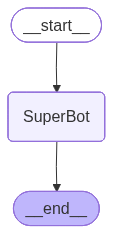

In [12]:
from IPython.display import Image,display

graph=StateGraph(State)

# Node
graph.add_node("SuperBot",superbot)

# Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

# Compile the graph
graph_builder=graph.compile()

#View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

# Graph invocation

In [13]:
graph_builder.invoke({"messages":"Hi, my name is Nicolas and I practice climbing"})

{'messages': [HumanMessage(content='Hi, my name is Nicolas and I practice climbing', additional_kwargs={}, response_metadata={}, id='f2fa6bbe-d77b-4a0a-b752-5c33bac965a9'),
  AIMessage(content='Nice to meet you, Nicolas. Climbing can be a fantastic sport for physical and mental challenges. What kind of climbing do you enjoy - bouldering, sport climbing, trad climbing, or ice climbing?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 45, 'total_tokens': 88, 'completion_time': 0.068110903, 'completion_tokens_details': None, 'prompt_time': 0.009501832, 'prompt_tokens_details': None, 'queue_time': 0.015632572, 'total_time': 0.077612735}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfcdc-fc54-72b3-a5b4-66c2d925a151-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'ou

In [14]:
# Streaming the response
graph_builder.stream({"messages":"Hi, my name is Nicolas and I practice climbing"})

<generator object Pregel.stream at 0x0000016A9DBEE2F0>

In [16]:
for event in graph_builder.stream({"messages":"Hi, my name is Nicolas and I practice climbing"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="Hello Nicolas, it's great to meet you. Climbing is an excellent sport that requires a combination of physical strength, mental focus, and strategy. What type of climbing do you enjoy the most - sport climbing, bouldering, trad climbing, or perhaps ice climbing?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.086517393, 'completion_tokens_details': None, 'prompt_time': 0.017148371, 'prompt_tokens_details': None, 'queue_time': 0.048142585, 'total_time': 0.103665764}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e09ee421cf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfcdf-bf61-7e01-ac96-47b1d5ffbc1a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 56, 'total_tokens': 101})]}}


In [17]:
for event in graph_builder.stream({"messages":"Hi, my name is Nicolas and I practice climbing"},stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hi, my name is Nicolas and I practice climbing', additional_kwargs={}, response_metadata={}, id='201537b2-9b7b-46ee-b8cb-a325fa72bdf5')]}
{'messages': [HumanMessage(content='Hi, my name is Nicolas and I practice climbing', additional_kwargs={}, response_metadata={}, id='201537b2-9b7b-46ee-b8cb-a325fa72bdf5'), AIMessage(content='Hello Nicolas, nice to meet you. Climbing can be a fantastic sport for both physical and mental well-being. What type of climbing do you practice? Are you into bouldering, sport climbing, traditional climbing, or perhaps indoor climbing?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 45, 'total_tokens': 95, 'completion_time': 0.078073113, 'completion_tokens_details': None, 'prompt_time': 0.002796433, 'prompt_tokens_details': None, 'queue_time': 0.020284476, 'total_time': 0.080869546}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6a1eabf260', 'service_tier

In [18]:
for event in graph_builder.stream({"messages":"Hi, my name is Nicolas and I practice climbing"},stream_mode="updates"):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Nicolas. Climbing can be an exhilarating sport, physically and mentally challenging, but also incredibly rewarding. What type of climbing do you enjoy the most? Indoor climbing, outdoor rock climbing, or perhaps bouldering?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 45, 'total_tokens': 95, 'completion_time': 0.081183211, 'completion_tokens_details': None, 'prompt_time': 0.00463482, 'prompt_tokens_details': None, 'queue_time': 0.047882262, 'total_time': 0.085818031}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4848f70c04', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfce2-5b2f-7133-a1ef-2117bf77f709-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 50, 'total_tokens': 95})]}}
